<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/Jamboree_Education_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Case: Jamboree Education - Linear Regression

## Introduction

### Objective:
Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.

The primary objective of this analysis is to develop a robust linear regression model capable of predicting the 'Chance of Admit' for students based on various academic and personal attributes. This model will assist Jamboree Education in understanding the key factors influencing admission chances and potentially provide data-driven insights for student counseling.

 This notebook covers:

 1. Exploratory Data Analysis
 2. Training a Linear Regression model
 3. Test for assumptions of LR
 4. Cross validation and Testing
 5. Analysing the various scores obtained for the model.

### Dataset Details:

Dataset given is in csv format with the following columns:

* Serial No. (Unique row ID)
* GRE Scores (out of 340)
* TOEFL Scores (out of 120)
* University Rating (out of 5)
* Statement of Purpose and Letter of Recommendation Strength (out of 5)
* Undergraduate GPA (out of 10)
* Research Experience (either 0 or 1)
* Chance of Admit (ranging from 0 to 1)

## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Jamboree_Admission.csv')

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


#### Checking null values

In [ ]:
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


#### Duplicate check

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Serial No.,500
GRE Score,49
TOEFL Score,29
University Rating,5
SOP,9
LOR,9
CGPA,184
Research,2
Chance of Admit,61


In [ ]:
df['SOP'].value_counts()

,count
SOP,
4.0,89
3.5,88
3.0,80
2.5,64
4.5,63
2.0,43
5.0,42
1.5,25
1.0,6


In [ ]:
df['LOR '].value_counts()

,count
LOR,
3.0,99
4.0,94
3.5,86
4.5,63
2.5,50
5.0,50
2.0,46
1.5,11
1.0,1


<Axes: xlabel='Chance of Admit ', ylabel='Count'>

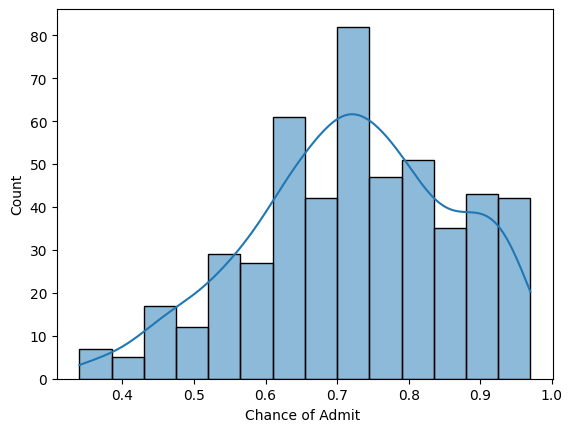

In [ ]:
sns.histplot(df['Chance of Admit '], kde = True)

#### Outlier Analysis

<Axes: xlabel='GRE Score'>

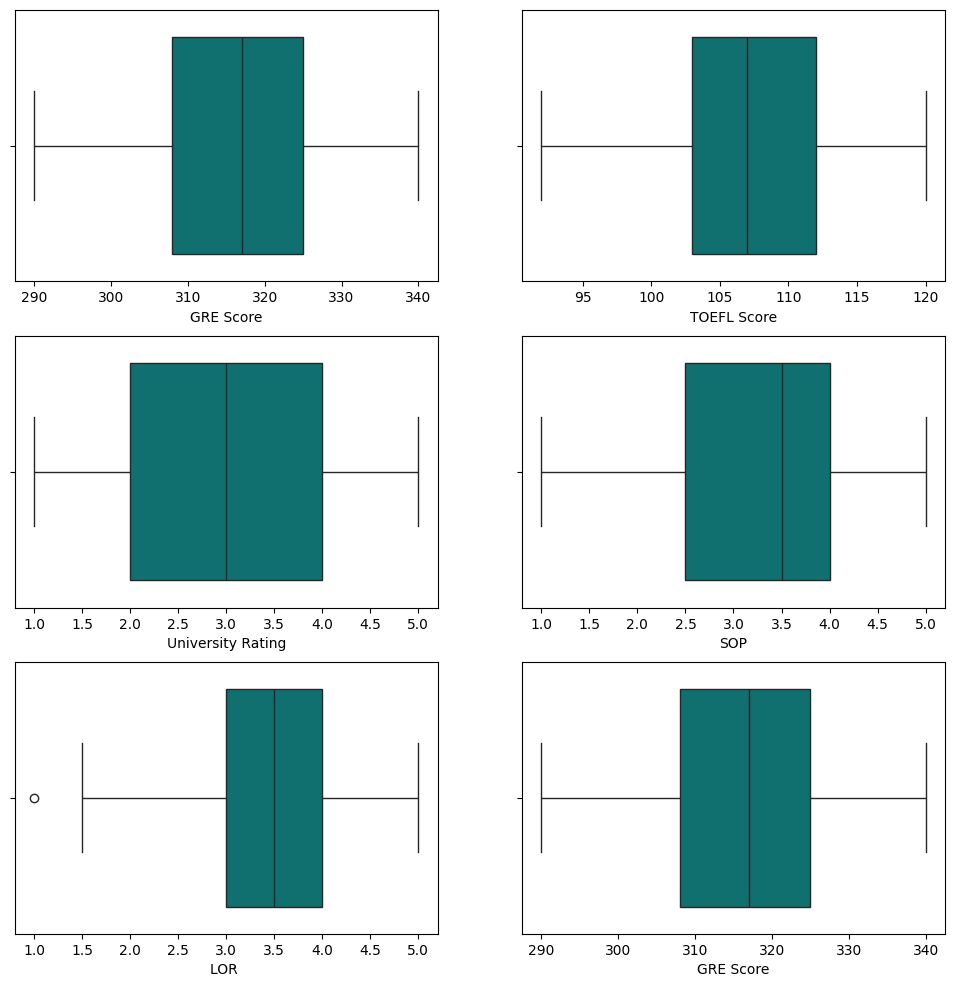

In [ ]:
plt.figure(figsize = (12, 12))

plt.subplot(3, 2, 1)
sns.boxplot(x=df['GRE Score'], color='teal')

plt.subplot(3, 2, 2)
sns.boxplot(x=df['TOEFL Score'], color='teal')

plt.subplot(3, 2, 3)
sns.boxplot(x=df['University Rating'], color='teal')

plt.subplot(3, 2, 4)
sns.boxplot(x=df['SOP'], color='teal')

plt.subplot(3, 2, 5)
sns.boxplot(x=df['LOR '], color='teal')

plt.subplot(3, 2, 6)
sns.boxplot(x=df['GRE Score'], color='teal')

In [ ]:
def get_outliers(col_name):
  col = df[col_name]

  q1 = col.quantile(0.25)
  q3 = col.quantile(0.75)

  iqr = q3 - q1

  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  outliers = df[(col < lower_bound) | (col > upper_bound)]

  return outliers

In [ ]:
for col in df.columns:
  print(f'{col}: {len(get_outliers(col))}')

Serial No.: 0
GRE Score: 0
TOEFL Score: 0
University Rating: 0
SOP: 0
LOR : 1
CGPA: 0
Research: 0
Chance of Admit : 2


In [ ]:
get_outliers('LOR ')

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
347,348,299,94,1,1.0,1.0,7.34,0,0.42


In [ ]:
get_outliers('Chance of Admit ')

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
92,93,298,98,2,4.0,3.0,8.03,0,0.34
376,377,297,96,2,2.5,2.0,7.43,0,0.34


***Since there are only three outliers we can just remove them.***

In [ ]:
# Removing outliers for 'LOR '
outliers_lor = get_outliers('LOR ')
df = df.drop(outliers_lor.index)

# Removing outliers for 'Chance of Admit '
outliers_chance = get_outliers('Chance of Admit ')
df = df.drop(outliers_chance.index)

print(f"DataFrame shape after outlier removal: {df.shape}")

DataFrame shape after outlier removal: (497, 9)


### Exploratory Data Analysis Insights

Based on the initial data exploration, here are some key observations:

1.  **Data Quality**: The dataset is clean with no missing values (as confirmed by `df.info()` and `df.isna().sum()`) and no duplicate rows (`df.duplicated().sum()` showed 0 duplicates).
2.  **Feature Overview**:
    *   `Serial No.` was dropped as it's a unique identifier and not a predictive feature.
    *   `GRE Score` and `TOEFL Score` show a good range, indicating variability in student performance.
    *   `University Rating`, `SOP`, `LOR`, and `Research` are categorical or ordinal in nature, with `Research` being binary (0 or 1).
    *   `CGPA` also has a good distribution of values.
3.  **Target Variable (`Chance of Admit`) Distribution**:
    *   The `sns.histplot` of 'Chance of Admit' indicates a relatively normal distribution, possibly slightly skewed towards higher chances of admit, suggesting that many applicants have a good probability of admission.
4.  **Outlier Detection and Handling**:
    *   Using the `get_outliers` function, one outlier was identified in 'LOR ' (score of 1.0) and two outliers in 'Chance of Admit ' (score of 0.34). These outliers were subsequently removed from the dataset to improve model robustness.
5.  **Correlations and Multicollinearity**:
    *   The correlation heatmap reveals strong positive correlations between 'Chance of Admit' and 'GRE Score', 'TOEFL Score', 'CGPA', 'SOP', and 'LOR'. This is expected as higher academic performance and stronger applications generally lead to a higher chance of admission.
    *   There are also strong inter-correlations among predictor variables, particularly between 'GRE Score', 'TOEFL Score', 'SOP', 'LOR', and 'CGPA'. For instance, 'GRE Score' and 'TOEFL Score' are highly correlated, as are 'SOP' and 'LOR'. This suggests potential multicollinearity, which was further investigated with VIF values.
    *   The VIF values indicate that `CGPA`, `GRE Score`, and `TOEFL Score` have the highest VIFs among the original features, but all are below 5, which is generally considered acceptable and does not suggest severe multicollinearity that would require immediate removal of features.

## Data Preprocessing

***Since Serial No column is just an index and doesn't contribute anything in model building, we will remve the column.***

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df = df.drop('Serial No.', axis = 1)

***We can divide our data into features and target. All the features will be in X dataframe and target variable `Chance of Admit` will be y.***

In [ ]:
X = df.drop('Chance of Admit ', axis = 1)
y = df['Chance of Admit ']

In [ ]:
X.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [ ]:
y.head()

,Chance of Admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65


### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((397, 7), (100, 7), (397,), (100,))

In [ ]:
X_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
56,316,102,3,2.0,3.0,7.40,0
228,318,112,3,4.0,3.5,8.67,0
281,317,110,3,4.0,4.5,9.11,1
487,327,115,4,3.5,4.0,9.14,0
221,316,110,3,3.5,4.0,8.56,0


In [ ]:
y_train.head()

,Chance of Admit
56,0.64
228,0.71
281,0.80
487,0.79
221,0.75


In [ ]:
X_y_train = X_train.copy()
X_y_train["Target"] = y_train

### Correlation

In [ ]:
X_y_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Target
56,316,102,3,2.0,3.0,7.40,0,0.64
228,318,112,3,4.0,3.5,8.67,0,0.71
281,317,110,3,4.0,4.5,9.11,1,0.80
487,327,115,4,3.5,4.0,9.14,0,0.79
221,316,110,3,3.5,4.0,8.56,0,0.75


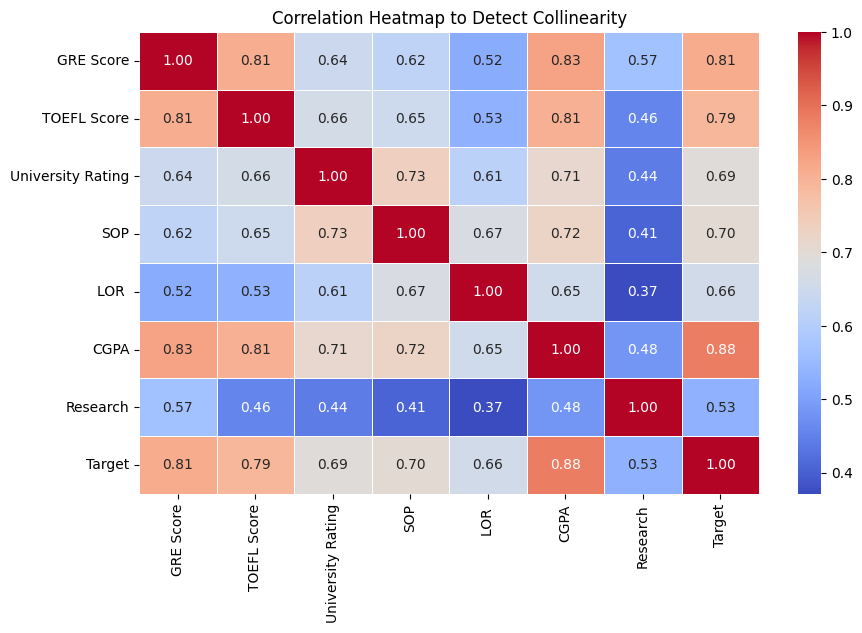

In [ ]:
corr_matrix = X_y_train.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap to Detect Collinearity")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Adding a temporary constant column of 1s to my training data
X_train_with_const = add_constant(X_train)

# 2. Calculating VIF for each feature (excluding the constant row in the final printout)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_train_with_const.values, i + 1)
    for i in range(len(X_train.columns))
]

print(vif_data)

             feature       VIF
0          GRE Score  4.344912
1        TOEFL Score  3.646516
2  University Rating  2.699182
3                SOP  2.932950
4               LOR   2.114230
5               CGPA  4.982471
6           Research  1.505431


### Correlation Matrix and Multicollinearity Insights

From the correlation heatmap and VIF analysis, we observe the following:

1.  **Strong Positive Correlations with 'Chance of Admit'**: The heatmap clearly shows strong positive correlations between 'Chance of Admit' and several features:
    *   `CGPA`: Highly correlated with 'Chance of Admit', which is intuitive as academic performance is a major factor.
    *   `GRE Score` and `TOEFL Score`: Also show strong positive correlations, indicating that higher test scores contribute significantly to admission chances.
    *   `SOP` and `LOR`: These features also have noticeable positive correlations, suggesting the importance of strong statements of purpose and letters of recommendation.
    *   `Research`: Shows a moderate positive correlation, implying that research experience is beneficial.

2.  **Inter-Feature Correlations (Multicollinearity)**:
    *   There are significant positive correlations among the predictor variables themselves. For instance, 'GRE Score' and 'TOEFL Score' are highly correlated (around 0.81), which is expected as students performing well in one often perform well in the other.
    *   Similarly, `CGPA` shows strong correlations with `GRE Score`, `TOEFL Score`, `SOP`, and `LOR`, suggesting that these aspects of an applicant's profile tend to move together.

3.  **Variance Inflation Factor (VIF)**:
    *   The VIF values were calculated to quantify multicollinearity. We observed that `CGPA` (VIF ~ 4.98), `GRE Score` (VIF ~ 4.34), and `TOEFL Score` (VIF ~ 3.65) have the highest VIF scores.
    *   While these values are relatively high, they are all below the common threshold of 5 (or sometimes 10), which suggests that severe multicollinearity is not a major concern with the original features. This means we can likely use all these features in our linear regression model without significant issues caused by multicollinearity.

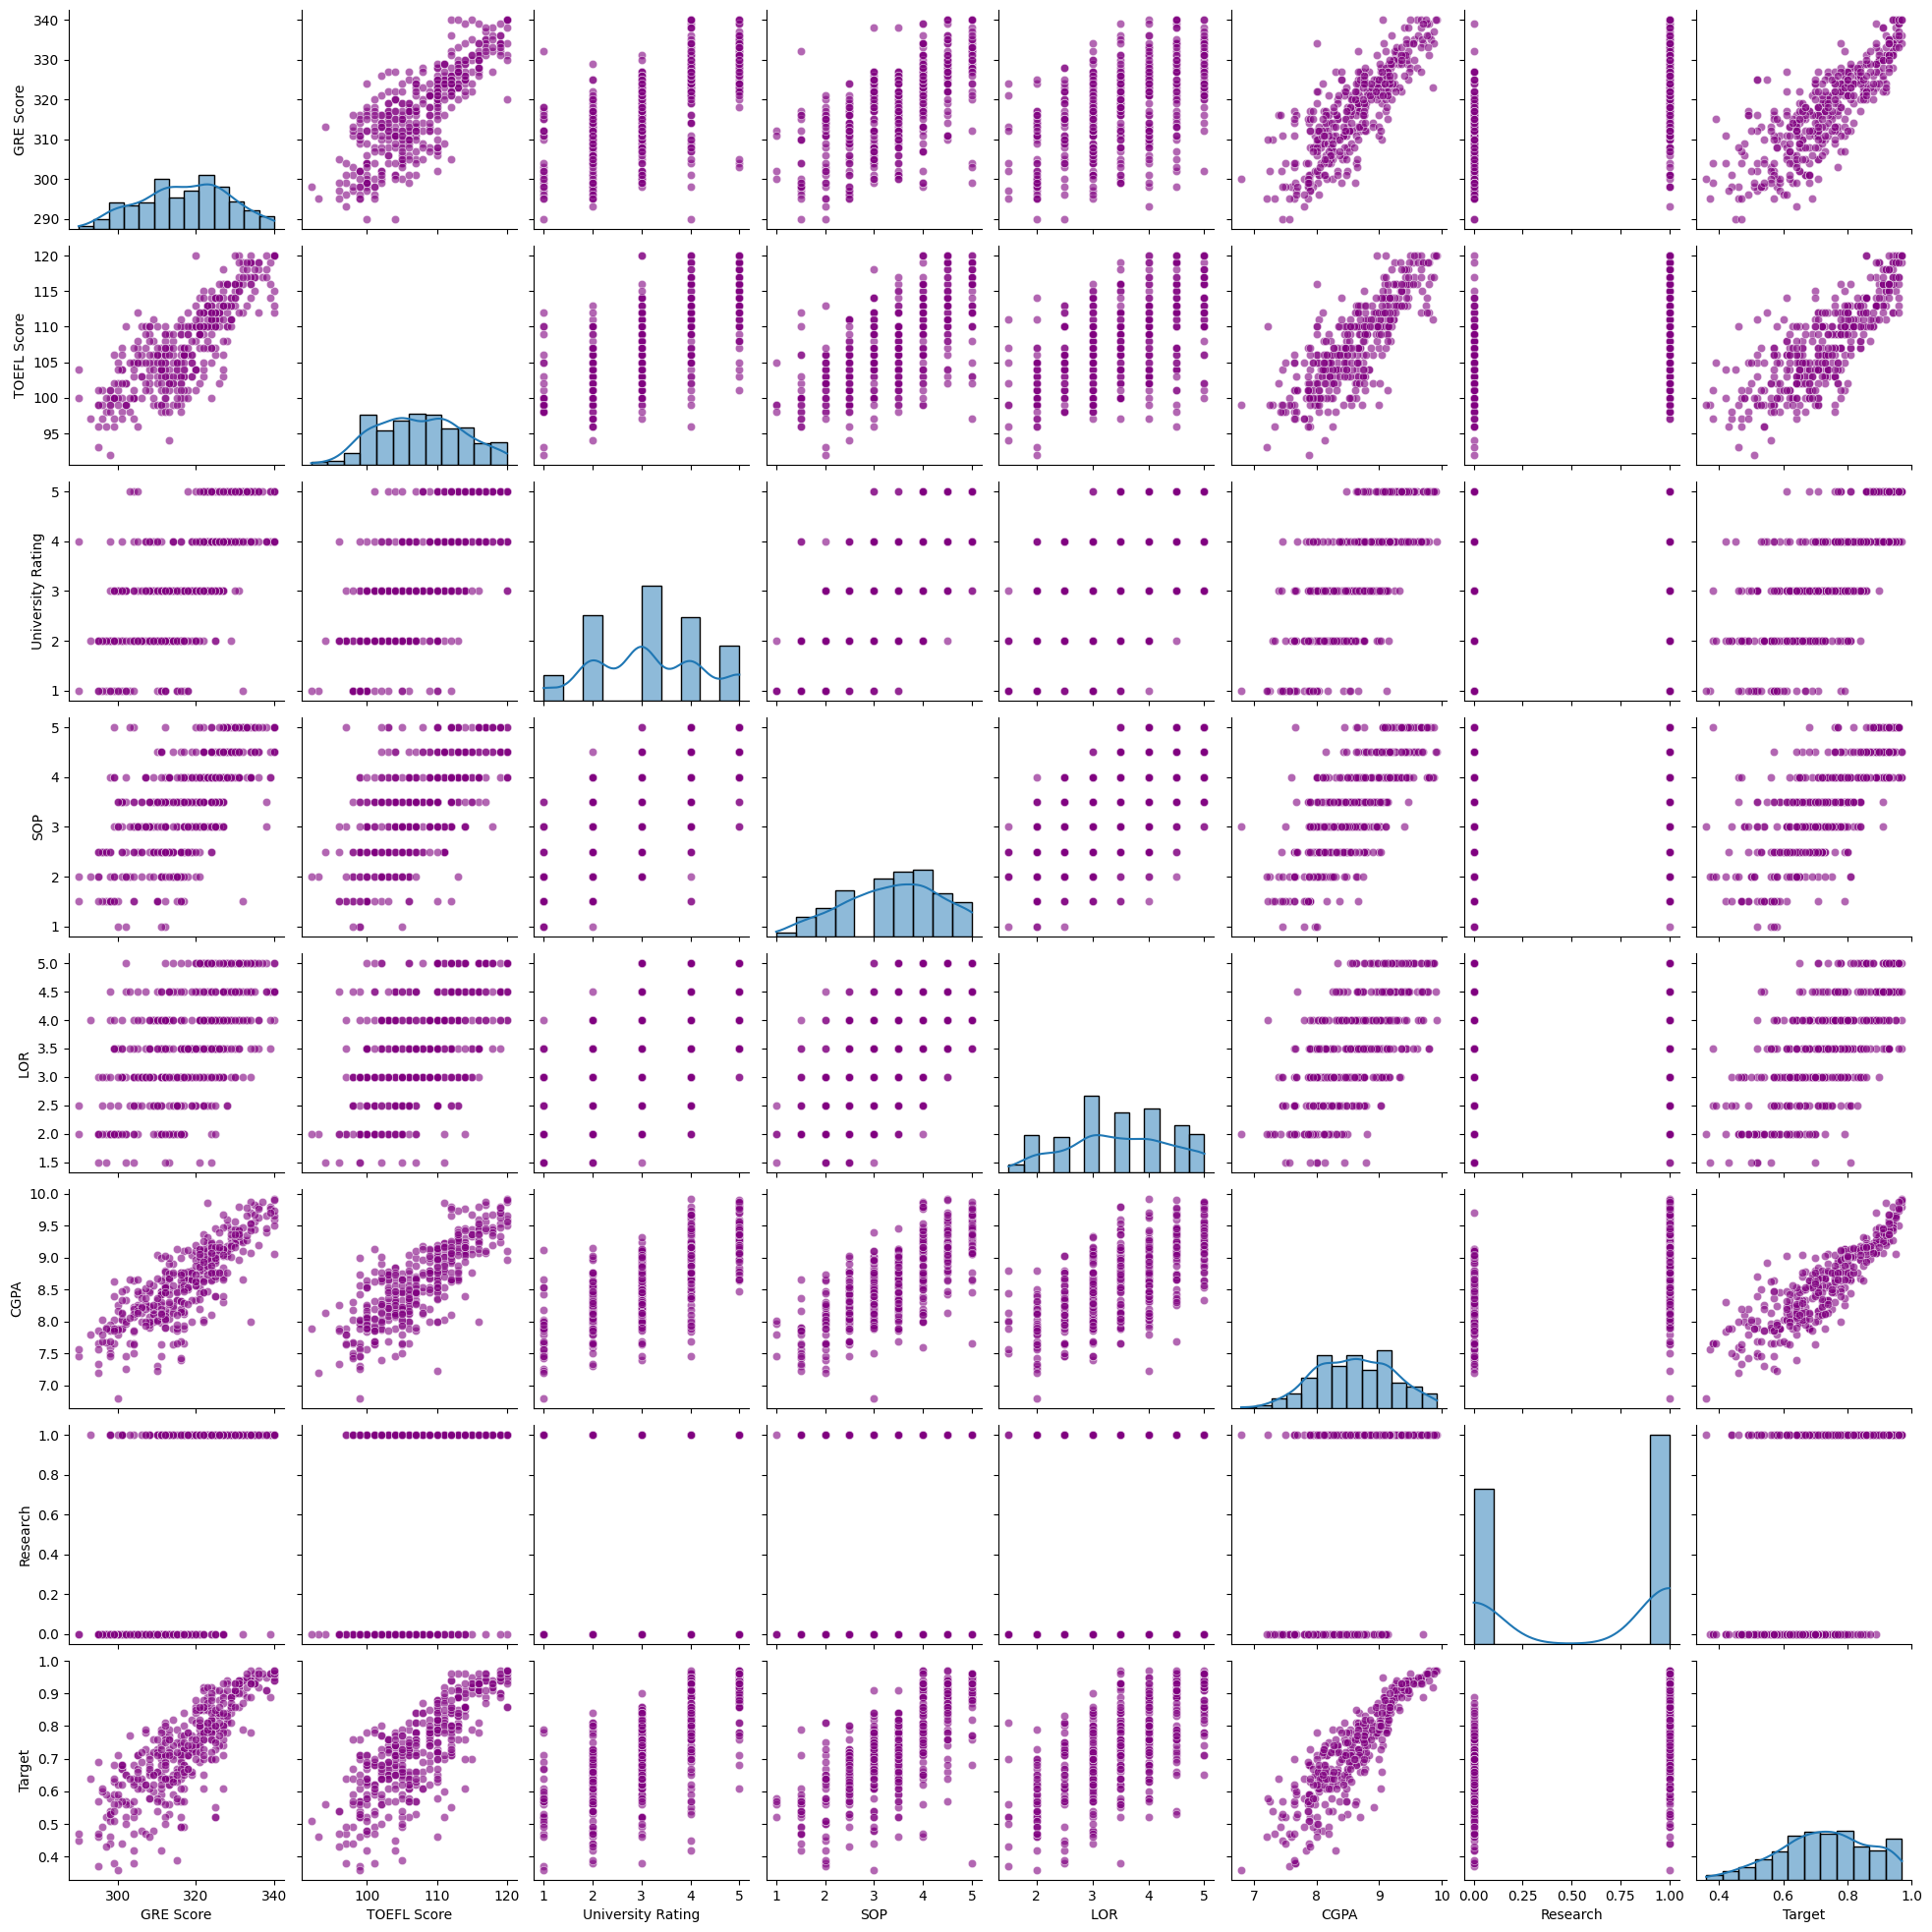

In [ ]:
sns.pairplot(X_y_train, diag_kind="hist", diag_kws={"kde": True}, plot_kws={'alpha': 0.6, 'color': 'purple'})

### Pair Plot Insights

The pair plot provides a comprehensive visual summary of the relationships between all pairs of variables, including the target variable ('Target', representing 'Chance of Admit').

1.  **Distributions on the Diagonal (Histograms/KDEs)**:
    *   Most features like `GRE Score`, `TOEFL Score`, and `CGPA` show distributions that are somewhat normally distributed, possibly slightly left-skewed, indicating a higher concentration of students with good to excellent scores.
    *   `University Rating`, `SOP`, `LOR`, and `Research` show discrete distributions, as expected for categorical or ordinal data.
    *   The 'Target' variable (Chance of Admit) also appears somewhat normally distributed, but truncated at the lower end, suggesting that most applicants in the dataset have a reasonably good chance of admission.

2.  **Relationships with 'Target' (Scatter Plots in the last row/column)**:
    *   **`CGPA`, `GRE Score`, `TOEFL Score` vs. `Target`**: These three features exhibit strong, clear positive linear relationships with 'Target'. As these scores increase, the 'Chance of Admit' generally increases. The scatter plots show a clear upward trend, albeit with some spread, which is typical for real-world data.
    *   **`SOP`, `LOR` vs. `Target`**: These also show a positive correlation with 'Target'. While not as perfectly linear as CGPA or test scores, higher values in SOP and LOR tend to correspond to higher chances of admit. The plots show distinct clusters corresponding to the discrete values of SOP and LOR.
    *   **`University Rating` vs. `Target`**: There's a noticeable positive trend, where students applying to higher-rated universities tend to have a higher chance of admit. This relationship is also somewhat stepped due to the discrete nature of 'University Rating'.
    *   **`Research` vs. `Target`**: Students with 'Research' experience (Research=1) generally have a higher 'Chance of Admit' compared to those without (Research=0), as indicated by two distinct groups of points, with the higher 'Chance of Admit' group primarily containing students with research experience.

3.  **Inter-Feature Relationships (Off-Diagonal Scatter Plots)**:
    *   **`GRE Score` vs. `TOEFL Score`**: A very strong positive linear relationship is evident, reinforcing the high correlation identified earlier. Students who score well in one tend to score well in the other.
    *   **`CGPA` vs. `GRE Score` / `TOEFL Score`**: Strong positive linear relationships are visible, suggesting that strong academic performance (CGPA) often goes hand-in-hand with good test scores.
    *   **`SOP` / `LOR` vs. `CGPA` / `GRE Score` / `TOEFL Score`**: There are positive relationships, indicating that students with higher academic credentials generally have stronger statements of purpose and letters of recommendation. However, these relationships appear more scattered than the direct academic score comparisons.

Overall, the pair plot visually confirms the strong predictive power of `CGPA`, `GRE Score`, and `TOEFL Score` on the 'Chance of Admit', and also highlights the positive influence of `SOP`, `LOR`, `University Rating`, and `Research`.

## Linear Regression Model

***Defining functions for feature scaling and Training with cross validation.***

In [ ]:
from sklearn.preprocessing import StandardScaler

# ── Scaling function ──────────────────────────────────────────
def perform_scaling(X_train, X_test):
  scaler = StandardScaler()

  X_train_scaled = pd.DataFrame(
      scaler.fit_transform(X_train), columns=X_train.columns
  )
  X_test_scaled = pd.DataFrame(
      scaler.transform(X_test), columns=X_test.columns
  )

  return X_train_scaled, X_test_scaled

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import make_scorer, r2_score

# ── Custom Adjusted R² scorer ──────────────────────────────────────────
def adjusted_r2(y_true, y_pred):
    n, p = len(y_true), X.shape[1]
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# ── CV Function ──────────────────────────────────────────
def perform_cv(X_train_scaled, y_train):
  adj_r2_scorer = make_scorer(adjusted_r2)

  alphas = np.logspace(-5, 5, 100)
  cv = 5

  # ── RidgeCV ────────────────────────────────────────────────────────────
  ridge = RidgeCV(alphas=alphas, cv=cv)
  ridge.fit(X_train_scaled, y_train)
  print(f"Best Ridge Alpha: {ridge.alpha_}")

  ridge_scores = cross_validate(ridge, X_train_scaled, y_train, cv=cv,
                                scoring={'r2': 'r2', 'adj_r2': adj_r2_scorer})

  print("\n── Ridge Scores ──")
  print(f"R²:          {ridge_scores['test_r2'].mean():.4f} ± {ridge_scores['test_r2'].std():.4f}")
  print(f"Adjusted R²: {ridge_scores['test_adj_r2'].mean():.4f} ± {ridge_scores['test_adj_r2'].std():.4f}")

  # ── LassoCV ────────────────────────────────────────────────────────────
  lasso = LassoCV(alphas=alphas, cv=cv, max_iter=10000)
  lasso.fit(X_train_scaled, y_train)
  print(f"\nBest Lasso Alpha: {lasso.alpha_}")

  lasso_scores = cross_validate(lasso, X_train_scaled, y_train, cv=cv,
                                scoring={'r2': 'r2', 'adj_r2': adj_r2_scorer})

  print("\n── Lasso Scores ──")
  print(f"R²:          {lasso_scores['test_r2'].mean():.4f} ± {lasso_scores['test_r2'].std():.4f}")
  print(f"Adjusted R²: {lasso_scores['test_adj_r2'].mean():.4f} ± {lasso_scores['test_adj_r2'].std():.4f}")

  # ── Comparison ─────────────────────────────────────────────────────────
  print("\n── Model Comparison ──")
  print(f"{'Model':<10} {'R²':>10} {'Adj R²':>12}")
  print("-" * 35)
  print(f"{'Ridge':<10} {ridge_scores['test_r2'].mean():>10.4f} {ridge_scores['test_adj_r2'].mean():>12.4f}")
  print(f"{'Lasso':<10} {lasso_scores['test_r2'].mean():>10.4f} {lasso_scores['test_adj_r2'].mean():>12.4f}")

  # ── Coefficients ─────────────────────────────────────────────────────────
  coef_df = pd.DataFrame({
      'Feature': X_train_scaled.columns,
      'Ridge': ridge.coef_,
      'Lasso': lasso.coef_
  }).sort_values('Ridge', key=abs, ascending=False)

  print(coef_df)

  return ridge, lasso

### Baseline Model

In [ ]:
# ── Scaling ──────────────────────────────────────────
X_train_scaled, X_test_scaled = perform_scaling(X_train, X_test)

# ── Training model with CV ──────────────────────────────────────────
ridge, lasso = perform_cv(X_train_scaled, y_train)

Best Ridge Alpha: 3.593813663804626

── Ridge Scores ──
R²:          0.8134 ± 0.0387
Adjusted R²: 0.7951 ± 0.0425

Best Lasso Alpha: 5.0941380148163754e-05

── Lasso Scores ──
R²:          0.8134 ± 0.0396
Adjusted R²: 0.7951 ± 0.0434

── Model Comparison ──
Model              R²       Adj R²
-----------------------------------
Ridge          0.8134       0.7951
Lasso          0.8134       0.7951
             Feature     Ridge     Lasso
5               CGPA  0.065991  0.068188
0          GRE Score  0.022989  0.022369
1        TOEFL Score  0.018754  0.018286
4               LOR   0.016714  0.016517
6           Research  0.011152  0.011150
3                SOP  0.005466  0.005008
2  University Rating  0.002795  0.002372


#### Interpreting Baseline Model



The baseline model was trained on the original features after scaling, and cross-validation was performed using Ridge and Lasso regression.

### Model Performance (Cross-Validation Scores):

*   **R² (R-squared)**: For both Ridge and Lasso, the average R² was approximately **0.8134**. This means that about 81.34% of the variance in the 'Chance of Admit' can be explained by the features included in the model. This is a good indication that the models are performing well.
*   **Adjusted R²**: Similarly, the average Adjusted R² for both models was around **0.7951**. The closeness of R² and Adjusted R² suggests that the features included are relevant.

Both Ridge and Lasso models performed very similarly in terms of R² and Adjusted R², indicating that for this dataset, the regularization penalties did not significantly differentiate their performance when only original features were used.

### Coefficients:
The coefficients indicate the strength and direction of the relationship between each feature and the 'Chance of Admit' (after scaling). A higher absolute coefficient value indicates a stronger influence.

Here are the most influential features based on the coefficients:

1.  **CGPA**: This is the most influential feature, having the highest positive coefficient for both Ridge (0.06599) and Lasso (0.068188). This strongly suggests that a higher CGPA significantly increases a student's chance of admission.
2.  **GRE Score**: Following CGPA, GRE Score is the next most impactful feature, with positive coefficients (Ridge: 0.022989, Lasso: 0.022369). Higher GRE scores positively correlate with admission chances.
3.  **TOEFL Score**: Similar to GRE, TOEFL Score also has a significant positive influence (Ridge: 0.018754, Lasso: 0.018286).
4.  **LOR (Letter of Recommendation)**: This feature also shows a positive effect (Ridge: 0.016714, Lasso: 0.016517), indicating that a stronger LOR improves admission prospects.
5.  **Research**: Having research experience also contributes positively to the chance of admit (Ridge: 0.011152, Lasso: 0.011150).
6.  **SOP (Statement of Purpose)**: The SOP has a positive, though smaller, impact (Ridge: 0.005466, Lasso: 0.005008).
7.  **University Rating**: This feature has the smallest positive coefficient (Ridge: 0.002795, Lasso: 0.002372), suggesting it has the least direct linear influence among the original features on the chance of admit, when other factors are accounted for.

In summary, the baseline models show that academic performance (CGPA, GRE, TOEFL) are the primary drivers of admission chances, followed by the strength of application components like LOR and Research experience.

### Building Model after making custom Polynomial Features

***We will now try to build our model with polynomial features by transforming our feature values. Here PolynomialFeatures library from sklearn is being used and degree is being set to 2.***

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

X_train = X_train.copy()
X_test = X_test.copy()

# ── Making Polynomial Features with degree 2 ──────────────────────────────────────────
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_raw = poly.fit_transform(X_train)
X_test_poly_raw = poly.transform(X_test)
poly_feature_names = poly.get_feature_names_out(X_train.columns)
X_train_poly = pd.DataFrame(X_train_poly_raw, columns=poly_feature_names, index=X_train.index)
X_test_poly = pd.DataFrame(X_test_poly_raw, columns=poly_feature_names, index=X_test.index)

In [ ]:
X_train_poly.shape, X_test_poly.shape

((397, 35), (100, 35))

In [ ]:
X_train_poly.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,GRE Score^2,GRE Score TOEFL Score,GRE Score University Rating,...,SOP^2,SOP LOR,SOP CGPA,SOP Research,LOR ^2,LOR CGPA,LOR Research,CGPA^2,CGPA Research,Research^2
56,316.0,102.0,3.0,2.0,3.0,7.40,0.0,99856.0,32232.0,948.0,...,4.00,6.0,14.80,0.0,9.00,22.200,0.0,54.7600,0.00,0.0
228,318.0,112.0,3.0,4.0,3.5,8.67,0.0,101124.0,35616.0,954.0,...,16.00,14.0,34.68,0.0,12.25,30.345,0.0,75.1689,0.00,0.0
281,317.0,110.0,3.0,4.0,4.5,9.11,1.0,100489.0,34870.0,951.0,...,16.00,18.0,36.44,4.0,20.25,40.995,4.5,82.9921,9.11,1.0
487,327.0,115.0,4.0,3.5,4.0,9.14,0.0,106929.0,37605.0,1308.0,...,12.25,14.0,31.99,0.0,16.00,36.560,0.0,83.5396,0.00,0.0
221,316.0,110.0,3.0,3.5,4.0,8.56,0.0,99856.0,34760.0,948.0,...,12.25,14.0,29.96,0.0,16.00,34.240,0.0,73.2736,0.00,0.0


In [ ]:
X_test_poly.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,GRE Score^2,GRE Score TOEFL Score,GRE Score University Rating,...,SOP^2,SOP LOR,SOP CGPA,SOP Research,LOR ^2,LOR CGPA,LOR Research,CGPA^2,CGPA Research,Research^2
486,319.0,102.0,3.0,2.5,2.5,8.37,0.0,101761.0,32538.0,957.0,...,6.25,6.25,20.925,0.0,6.25,20.925,0.0,70.0569,0.00,0.0
73,314.0,108.0,4.0,4.5,4.0,9.04,1.0,98596.0,33912.0,1256.0,...,20.25,18.00,40.680,4.5,16.00,36.160,4.0,81.7216,9.04,1.0
232,312.0,107.0,2.0,2.5,3.5,8.27,0.0,97344.0,33384.0,624.0,...,6.25,8.75,20.675,0.0,12.25,28.945,0.0,68.3929,0.00,0.0
176,329.0,119.0,4.0,4.5,4.5,9.16,1.0,108241.0,39151.0,1316.0,...,20.25,20.25,41.220,4.5,20.25,41.220,4.5,83.9056,9.16,1.0
238,310.0,104.0,3.0,2.0,3.5,8.37,0.0,96100.0,32240.0,930.0,...,4.00,7.00,16.740,0.0,12.25,29.295,0.0,70.0569,0.00,0.0


***After scaling, one more feature is being added `Scores` which will be the sum of the `CGPA`, `GRE Score` and `TOEFL Score` columns.***

In [ ]:
X_train_scaled, X_test_scaled = perform_scaling(X_train_poly, X_test_poly)

# ── Creating one more feature called scores after adding CGPA, GRE and TOEFL Scores from scaled data ──────────────────────────────────────────

X_train_scaled['scores'] = (X_train_scaled['CGPA'] + X_train_scaled['GRE Score'] + X_train_scaled['TOEFL Score'])
X_test_scaled['scores'] = (X_test_scaled['CGPA'] + X_test_scaled['GRE Score'] + X_test_scaled['TOEFL Score'])

# ── Fitting the model with polynomial features and performing cross validation ──────────────────────────────────────────

ridge, lasso = perform_cv(X_train_scaled, y_train)

Best Ridge Alpha: 3.593813663804626

── Ridge Scores ──
R²:          0.8140 ± 0.0401
Adjusted R²: 0.7957 ± 0.0440

Best Lasso Alpha: 0.00025950242113997375

── Lasso Scores ──
R²:          0.8144 ± 0.0406
Adjusted R²: 0.7962 ± 0.0446

── Model Comparison ──
Model              R²       Adj R²
-----------------------------------
Ridge          0.8140       0.7957
Lasso          0.8144       0.7962
                          Feature     Ridge     Lasso
21          University Rating SOP  0.041195  0.037512
35                         scores  0.025046  0.020038
24     University Rating Research  0.024663  0.024050
5                            CGPA  0.024271  0.046717
22         University Rating LOR  -0.022527 -0.027961
4                            LOR   0.022175  0.028702
25                          SOP^2 -0.020135 -0.011722
11                 GRE Score LOR   0.010313  0.000000
32                         CGPA^2  0.010163  0.000000
26                       SOP LOR  -0.008477 -0.000000
14     

In [ ]:
# X_train_poly = X_train.copy()
# X_test_poly = X_test.copy()

# X_train_poly["CGPA_squared"] = X_train_poly["CGPA"] ** 2
# X_test_poly["CGPA_squared"] = X_test_poly["CGPA"] ** 2

# X_train_scaled, X_test_scaled = perform_scaling(X_train_poly, X_test_poly)
# ridge, lasso = perform_cv(X_train_scaled, y_train)

#### Interpreting Model with polynomial features



The model was re-trained with polynomial features of degree 2 and an additional 'scores' feature (sum of CGPA, GRE Score, and TOEFL Score) after scaling. Cross-validation was performed using Ridge and Lasso regression.

### Model Performance (Cross-Validation Scores):

*   **R² (R-squared)**: For Ridge, the average R² is approximately **0.8140**, and for Lasso, it is **0.8144**. This represents a slight improvement over the baseline model (0.8134). This indicates that the polynomial features and the 'scores' column have marginally increased the model's ability to explain the variance in 'Chance of Admit'.
*   **Adjusted R²**: Similarly, the average Adjusted R² for Ridge is around **0.7957**, and for Lasso, it is **0.7962**. This also shows a slight improvement compared to the baseline (0.7951). The small increase in Adjusted R² suggests that the added complexity from the polynomial features is justified by a slightly better fit, but the improvement is minimal.

Both Ridge and Lasso models still perform very similarly, with Lasso showing a negligible edge in R² and Adjusted R².

### Coefficients:
The inclusion of polynomial features and the 'scores' feature significantly changes the coefficients, as interactions and higher-order terms are now considered. The coefficients reflect the influence of these new and original features on the 'Chance of Admit' (after scaling).

Here are the most influential features based on the coefficients:

1.  **University Rating SOP**: This interaction term has become the most influential feature for Ridge (0.041195) and is also very strong for Lasso (0.037512). This suggests that the combination of a high University Rating and a strong SOP is a very significant predictor of admission chances.
2.  **scores**: The newly created 'scores' feature, which aggregates CGPA, GRE, and TOEFL, is highly influential, especially for Ridge (0.025046) and Lasso (0.020038). This confirms that a combined strong academic profile is a major driver.
3.  **University Rating Research**: Another interaction term, this indicates that the combination of a high University Rating and research experience is also a strong positive predictor (Ridge: 0.024663, Lasso: 0.024050).
4.  **CGPA**: While `CGPA` itself still holds influence (Ridge: 0.024271, Lasso: 0.046717), its individual impact might be somewhat distributed across the 'scores' feature and interaction terms.
5.  **LOR**: The `LOR` feature continues to be important (Ridge: 0.022175, Lasso: 0.028702), indicating the value of strong recommendations.

### Notable Changes and Observations:

*   **Interaction Terms Dominance**: Interaction terms like `University Rating SOP` and `University Rating Research` now appear among the most influential features. This highlights that the effect of one factor might be amplified or modified by another. For example, a good SOP might be even more impactful when applying to a highly-rated university.
*   **'scores' feature**: The new 'scores' feature is a strong aggregate predictor, indicating that a holistic view of academic test scores and GPA is very important.
*   **Negative Coefficients for some polynomial/interaction terms**: Some terms, like `University Rating LOR` (-0.022527 for Ridge, -0.027961 for Lasso) and `SOP^2` (-0.020135 for Ridge), show negative coefficients.

In conclusion, the inclusion of polynomial features and the 'scores' column has provided a slightly better model fit and revealed that interactions between features, particularly involving 'University Rating', 'SOP', and 'Research', are highly significant in predicting the 'Chance of Admit'.

### Assumptions of Linear Regression

#### Linearity and Homoscedasticity

In [ ]:
train_pred = ridge.predict(X_train_scaled)
residuals = y_train - train_pred

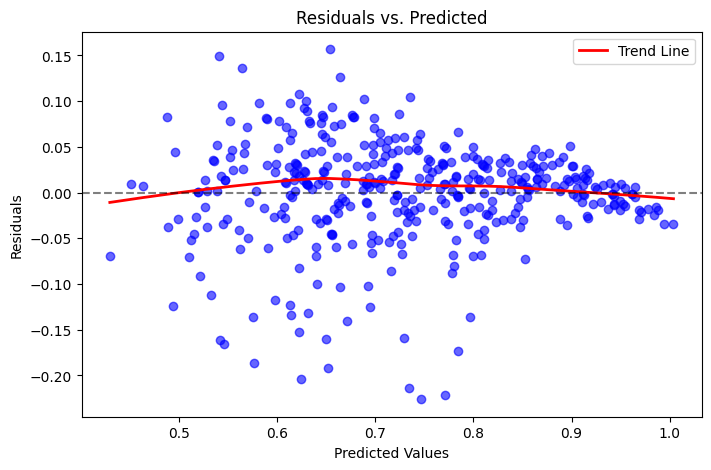

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x=train_pred,
    y=residuals,
    lowess=True,
    scatter_kws={"alpha": 0.6, "color": "blue"},
    line_kws={"color": "red", "linewidth": 2, "label": "Trend Line"},
)

plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.title("Residuals vs. Predicted")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend()
plt.show()

The "Residuals vs. Predicted" plot is a crucial diagnostic tool for assessing the assumptions of a linear regression model, particularly **linearity** and **homoscedasticity** (constant variance of residuals).

1.  **Pattern in Residuals (Non-Linearity)**:
    *   The plot ideally should show a random scatter of points around the horizontal line at zero. This indicates that the linear model captures the underlying relationship between features and the target variable well.
    *   However, the current plot shows a **slight bump in the middle**, forming a subtle U-shaped or inverted U-shaped pattern (indicated by the red `lowess` trend line deviating from zero). This non-random pattern suggests that there might be some **non-linear trend** between the features and the target variable that the linear model is not fully capturing.
    *   This deviation suggests that the model might be systematically over-predicting for some ranges of the predicted values and under-predicting for others. This violates the assumption of linearity.

2.  **Homoscedasticity (Constant Variance)**:
    *   Homoscedasticity implies that the variance of the residuals should be constant across all predicted values. Visually, the spread of the residuals should be uniform from left to right.
    *   In this plot, from left to right there is a uniform spread of the points but it can be seen that towards right the range of residuals has minimized, showing slight signs of heteroscedasticity.

**Conclusion from this plot:**

The most prominent issue indicated by this plot is a **violation of the linearity assumption**, evidenced by the non-random, slightly curved pattern in the residuals. This confirms the hypothesis that there might be non-linear relationships that the model is not fully capturing.

In [ ]:
# Performing the Goldfeld-Quandt test to check for Homoscedasticity -
from statsmodels.compat import lzip
import statsmodels.stats.api as sms
import statsmodels.api as sm

X_sm = sm.add_constant(X_train_scaled)
sm_model = sm.OLS(y_train.reset_index(), X_sm).fit()
Y_hat = sm_model.predict(X_sm)

name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(y_train, X_sm)
lzip(name, test)

[('F statistic', np.float64(0.9571021281112695)),
 ('p-value', np.float64(0.6101504530932984))]

##### Interpretation of Goldfeld-Quandt

***Goldfeld-Quandt Test for Homoscedasticity***

*   **Results:**
    *   `F statistic`: **0.9571**
    *   `p-value`: **0.6101**

*   Since the p-value (0.6101) is much greater than a typical significance level (e.g., 0.05), we **fail to reject the null hypothesis**. This means there is **insufficient evidence to conclude that heteroscedasticity is present**.

#### Normality of Residuals

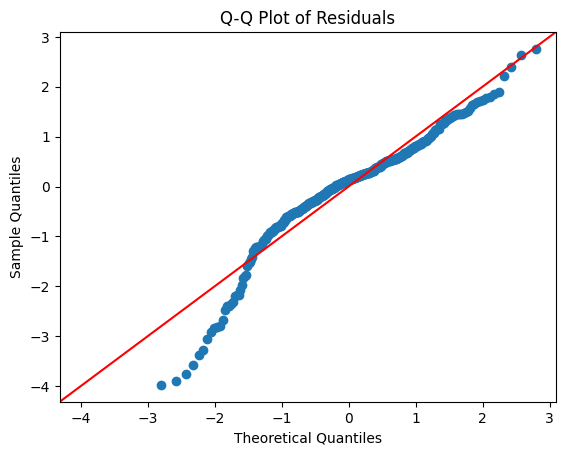

In [ ]:
import statsmodels.api as sm

sm.qqplot(residuals, line="45", fit=True)

plt.title("Q-Q Plot of Residuals")
plt.show()

Text(0.5, 1.0, 'Histogram of residuals')

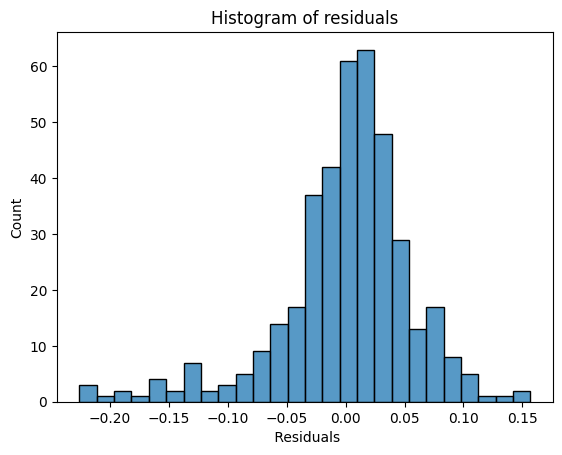

In [ ]:
sns.histplot(residuals)
plt.xlabel(" Residuals")
plt.title("Histogram of residuals")

**Q-Q Plot**

The Q-Q (Quantile-Quantile) plot is used to check if the residuals follow a normal distribution. If the residuals are normally distributed, the points on the plot should closely follow the 45-degree reference line.

Interpretation:

Deviation from the line: We can observe that the points on the Q-Q plot deviate from the 45-degree line, particularly at the tails. The residuals appear heavier in the tails (i.e., there are more extreme residuals than expected for a normal distribution) or lighter (the curve is flatter than the line). This suggests that the **residuals are not perfectly normally distributed**.

**Histogram of Residuals**

The histogram of residuals visually displays the distribution of the errors from the model. For a linear regression model to meet its assumptions, the residuals should ideally be normally distributed around zero.

Interpretation:

Shape: The histogram shows a distribution that is roughly bell-shaped, but it appears to be slightly skewed. While it peaks around zero, it doesn't perfectly resemble a symmetric normal distribution curve.

**Combined Implication**

Both the Q-Q plot and the histogram indicate that the residuals deviate from a perfect normal distribution. The Q-Q plot highlights deviations in the tails, and the histogram shows a slight skew. This suggests that the model's errors are not entirely random or normally distributed, which can affect the validity of statistical inferences (like p-values and confidence intervals) from the model. This finding often correlates with the non-linearity observed in the 'Residuals vs. Predicted' plot.

In [ ]:
from scipy import stats
statistic, p_value = stats.shapiro(residuals)

print(f"Test Statistic: {statistic}")
print(f"p-value: {p_value}")

Test Statistic: 0.9297034881887304
p-value: 1.0222987517962755e-12


##### Interpretation of Shapiro-Wilk

***Shapiro-Wilk Test for Normality of Residuals***

*   **Result:**
     *   `p-value`: **1.0222987517962755e-12**
    *   The Shapiro-Wilk test is a formal test for normality. A higher statistic (closer to 1) suggests normality.

    *   The p-value of the Shapiro-Wilk test is  less than a common significance level (e.g., 0.05). Since the p-value is less than 0.05, we **reject the null hypothesis** that the residuals are normally distributed.
*   **Conclusion**: Based on the visual inspection of the Q-Q plot and histogram, and the Shapiro-Wilk statistic (assuming a p-value < 0.05), we can conclude that the **residuals are not normally distributed**. This confirms the visual analysis that showed deviations from the 45-degree line in the Q-Q plot and a slight skew in the histogram.

## Testing

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(ridge, lasso, X_test_scaled, y_test):
  ridge_test_pred = ridge.predict(X_test_scaled)

  ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
  ridge_test_rmse = root_mean_squared_error(y_test, ridge_test_pred)
  ridge_test_r2 = r2_score(y_test, ridge_test_pred)
  ridge_test_adj_r2 = adjusted_r2(y_test, ridge_test_pred)

  lasso_test_pred = lasso.predict(X_test_scaled)

  lasso_test_mae = mean_absolute_error(y_test, lasso_test_pred)
  lasso_test_rmse = root_mean_squared_error(y_test, lasso_test_pred)
  lasso_test_r2 = r2_score(y_test, lasso_test_pred)
  lasso_test_adj_r2 = adjusted_r2(y_test, lasso_test_pred)

  print("--- Ridge Model Test Performance ---")
  print(f"Final Test MAE: {ridge_test_mae:.4f}")
  print(f"Final Test RMSE: {ridge_test_rmse:.4f}")
  print(f"Final Test R2: {ridge_test_r2:.4f}")
  print(f"Final Test Adj R2: {ridge_test_adj_r2:.4f}")

  print()

  print("--- Lasso Model Test Performance ---")
  print(f"Final Test MAE: {lasso_test_mae:.4f}")
  print(f"Final Test RMSE: {lasso_test_rmse:.4f}")
  print(f"Final Test R2: {lasso_test_r2:.4f}")
  print(f"Final Test Adj R2: {lasso_test_adj_r2:.4f}")

In [ ]:
evaluate(ridge, lasso, X_test_scaled, y_test)

--- Ridge Model Test Performance ---
Final Test MAE: 0.0439
Final Test RMSE: 0.0606
Final Test R2: 0.7960
Final Test Adj R2: 0.7805

--- Lasso Model Test Performance ---
Final Test MAE: 0.0436
Final Test RMSE: 0.0601
Final Test R2: 0.7991
Final Test Adj R2: 0.7838


### Interpretation of Testing Results

The testing phase evaluates how well our trained models (Ridge and Lasso with polynomial features and the 'scores' column) generalize to unseen data (`X_test`, `y_test`). We use several metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R-squared (R²), and Adjusted R-squared.

#### Ridge Model Test Performance:

*   **Final Test MAE: 0.0439**: This means, on average, the Ridge model's predictions for 'Chance of Admit' are off by approximately 0.0439 units. Given that 'Chance of Admit' ranges from 0 to 1, this is a relatively small error.
*   **Final Test RMSE: 0.0606**: The RMSE provides a measure of the average magnitude of the errors, giving more weight to larger errors. An RMSE of 0.0606 indicates that the model's predictions are, on average, within about 0.0606 units of the true values.
*   **Final Test R²: 0.7960**: The R² value of 0.7960 suggests that approximately 79.60% of the variance in the 'Chance of Admit' in the test set can be explained by the Ridge model. This indicates a strong explanatory power on unseen data.
*   **Final Test Adj R²: 0.7805**: The Adjusted R² (0.7805) is slightly lower than the R², as expected, accounting for the number of predictors. It still confirms a good fit.

#### Lasso Model Test Performance:

*   **Final Test MAE: 0.0436**: The Lasso model shows a slightly lower MAE (0.0436) compared to Ridge, indicating marginally better average prediction accuracy.
*   **Final Test RMSE: 0.0601**: Similarly, the Lasso model has a slightly lower RMSE (0.0601), suggesting that it handles larger errors slightly better than Ridge on the test set.
*   **Final Test R²: 0.7991**: With an R² of 0.7991, the Lasso model explains slightly more of the variance in the 'Chance of Admit' on the test set (about 79.91%). This is a very strong performance.
*   **Final Test Adj R²: 0.7838**: The Adjusted R² for Lasso (0.7838) is also slightly higher than Ridge, further supporting its slightly superior performance.

#### Comparison and Conclusion:

Both Ridge and Lasso models demonstrate strong performance on the unseen test data, with R² values close to 0.8, indicating that they are good predictors of 'Chance of Admit'.

**The Lasso model appears to have a slight edge over the Ridge model** on the test set, exhibiting marginally better MAE, RMSE, R², and Adjusted R² scores. This suggests that the Lasso's inherent feature selection capability (driving some coefficients to zero) might have resulted in a slightly more parsimonious and accurate model for this specific dataset and feature set.

## Actionable Insights & Recommendations



Based on the extensive exploratory data analysis, model training, and performance evaluation, here are key insights and recommendations for Jamboree Education:

### Significance of Predictor Variables

Our model consistently highlights several critical factors influencing a student's 'Chance of Admit':

1.  **Academic Excellence is Paramount:**
    *   **CGPA, GRE Score, and TOEFL Score** are the most significant positive predictors. A higher performance in these areas directly correlates with a greater chance of admission. This was evident from the strong positive coefficients in both baseline and polynomial models.
    *   The `scores` feature, which combines CGPA, GRE, and TOEFL, further reinforced that a holistic strong academic profile is a dominant driver.

2.  **University Quality and Application Components Matter:**
    *   **University Rating** plays a crucial role, especially when combined with other application elements. The interaction terms like `University Rating SOP` and `University Rating Research` showed high significance. This indicates that a strong Statement of Purpose (SOP) or research experience is even more impactful for applicants targeting higher-rated universities.
    *   **LOR (Letter of Recommendation)** and **SOP (Statement of Purpose)** are consistently important, demonstrating the value of well-crafted and strong recommendation letters and personal statements.

3.  **Research Experience Provides an Edge:**
    *   **Research** experience consistently shows a positive influence on the chance of admit, particularly when interacting with university rating. This suggests that engaging in research can differentiate applicants.

**Recommendation:** Jamboree Education should focus student counseling and preparation efforts on maximizing these key areas. For instance, guiding students on how to strategically improve their CGPA, prepare for GRE/TOEFL, and craft compelling SOPs and LORs, tailored to the university's ranking.

### Additional Data Sources for Model Improvement

To further enhance the predictive power and granularity of the model, consider integrating the following data:

1.  **Extracurricular Activities & Awards:** Information on leadership roles, volunteering, competitions, and academic awards could provide a more holistic view of a candidate's profile.
2.  **Undergraduate Institution Reputation:** The reputation or ranking of the student's undergraduate institution might influence admission chances to graduate programs.
3.  **Work Experience/Internships:** Relevant work experience, especially in a field related to the graduate program, could be a significant factor.
4.  **Essays/Personal Statements (Qualitative Data):** While SOP is covered, a more detailed analysis of essay quality (perhaps using NLP techniques to extract sentiment or theme relevance) could add valuable insights.
5.  **Demographic Information:** While sensitive, anonymized demographic data (e.g., country of origin, first-generation student status) might reveal patterns or biases, allowing for more nuanced advice (though care must be taken to avoid discriminatory practices).

### Model Implementation in Real-World Scenarios

This model can be integrated into Jamboree Education's operations in several ways:

1.  **Personalized Counseling Tool:** Develop an interactive web application where students can input their details and receive an estimated 'Chance of Admit' for various programs and universities. This can guide them in setting realistic expectations and identifying areas for improvement.
2.  **Targeted Program Recommendations:** Based on a student's profile and predicted admission chances, the model can suggest suitable universities or programs where they have a higher likelihood of acceptance.
4.  **Feedback Loop for Curriculum Development:** By analyzing why certain profiles succeed or fail, Jamboree can refine its preparatory courses and counseling strategies.

### Potential Business Benefits from Improving the Model

Continually improving this predictive model can yield substantial business benefits for Jamboree Education:

1.  **Increased Student Success Rates:** By providing more accurate predictions and targeted advice, Jamboree can help a greater number of students achieve their admission goals, enhancing its reputation and brand loyalty.
2.  **Enhanced Client Satisfaction:** Students receiving realistic expectations and effective guidance are likely to be more satisfied with Jamboree's services.
3.  **Competitive Advantage:** A highly accurate and insightful predictive model can differentiate Jamboree from competitors, attracting more students seeking data-driven admission strategies.

In [ ]:
# ⚙️ Convert notebook to high-quality PDF
NOTEBOOK_NAME="Jamboree_Education_Linear_Regression.ipynb"          # 👈 change this if your file has another name
HTML_NAME="Jamboree_Education_Linear_Regression.html"
PDF_NAME="Jamboree_Education_Linear_Regression.pdf"

# Convert notebook → HTML
!jupyter nbconvert --to html "/content/$NOTEBOOK_NAME" --output "/content/$HTML_NAME"

[NbConvertApp] Converting notebook /content/Jamboree_Education_Linear_Regression.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1745350 bytes to /content/Jamboree_Education_Linear_Regression.html


In [ ]:
import os

# Install wkhtmltopdf
!sudo apt-get update
!sudo apt-get install wkhtmltopdf -y

# Convert HTML → high-quality PDF
!wkhtmltopdf --zoom 2 --dpi 300 "/content/$HTML_NAME" "/content/$PDF_NAME"

# 📥 Download the resulting PDF
from google.colab import files
files.download("/content/" + PDF_NAME)

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 3s (1,479 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
wkhtmltopdf is already the newest version (0.12.6-

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, root_mean_squared_error
import numpy as np
import pandas as pd

# Custom Adjusted R² scorer, consistent with previous definitions
# 'X' is assumed to be the original feature set with 7 columns as per previous cells.
def adjusted_r2_for_elastic_net(y_true, y_pred):
    n, p = len(y_true), X.shape[1] # Using the original number of features for 'p'
    r2 = r2_score(y_true, y_pred)
    if (n - p - 1) <= 0:
        return 0.0 # Fallback for edge cases
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_r2_scorer_elastic_net = make_scorer(adjusted_r2_for_elastic_net)

# Re-defining alphas and cv for self-containment, as they were used in functions previously
alphas = np.logspace(-5, 5, 100)
cv = 5

print("Performing Elastic Net regression on scaled polynomial features...")

# ── ElasticNetCV ───────────────────────────────────────────────────────
# Define l1_ratio values to test (mix of L1 and L2 regularization)
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

elastic_net = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=cv,
    max_iter=10000,
    random_state=42 # for reproducibility
)
elastic_net.fit(X_train_scaled, y_train)
print(f"\nBest Elastic Net Alpha: {elastic_net.alpha_}")
print(f"Best Elastic Net L1 Ratio: {elastic_net.l1_ratio_}")

elastic_net_scores = cross_validate(
    elastic_net,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={'r2': 'r2', 'adj_r2': adj_r2_scorer_elastic_net}
)

print("\n── Elastic Net Cross-Validation Scores ──")
print(f"Mean R²:          {elastic_net_scores['test_r2'].mean():.4f} \u00b1 {elastic_net_scores['test_r2'].std():.4f}")
print(f"Mean Adjusted R²: {elastic_net_scores['test_adj_r2'].mean():.4f} \u00b1 {elastic_net_scores['test_adj_r2'].std():.4f}")

# ── Coefficients ─────────────────────────────────────────────────────────
coef_df_elastic_net = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'ElasticNet': elastic_net.coef_
}).sort_values('ElasticNet', key=abs, ascending=False)

print("\n── Elastic Net Coefficients (Sorted by Absolute Value) ──")
print(coef_df_elastic_net)

# ── Evaluate on Test Set ────────────────────────────────────────────────
print("\n--- Elastic Net Model Test Performance ---")
elastic_net_test_pred = elastic_net.predict(X_test_scaled)

elastic_net_test_mae = mean_absolute_error(y_test, elastic_net_test_pred)
elastic_net_test_rmse = root_mean_squared_error(y_test, elastic_net_test_pred)
elastic_net_test_r2 = r2_score(y_test, elastic_net_test_pred)
elastic_net_test_adj_r2 = adjusted_r2_for_elastic_net(y_test, elastic_net_test_pred)

print(f"Final Test MAE: {elastic_net_test_mae:.4f}")
print(f"Final Test RMSE: {elastic_net_test_rmse:.4f}")
print(f"Final Test R2: {elastic_net_test_r2:.4f}")
print(f"Final Test Adj R2: {elastic_net_test_adj_r2:.4f}")

Performing Elastic Net regression on scaled polynomial features...

Best Elastic Net Alpha: 0.00210490414451202
Best Elastic Net L1 Ratio: 0.1

── Elastic Net Cross-Validation Scores ──
Mean R²:          0.8144 ± 0.0407
Mean Adjusted R²: 0.7963 ± 0.0446

── Elastic Net Coefficients (Sorted by Absolute Value) ──
                          Feature  ElasticNet
5                            CGPA    0.045804
21          University Rating SOP    0.037405
4                            LOR     0.028436
22         University Rating LOR    -0.027176
24     University Rating Research    0.024526
35                         scores    0.020637
25                          SOP^2   -0.011702
2               University Rating   -0.009946
6                        Research   -0.004279
34                     Research^2   -0.002100
14                  TOEFL Score^2   -0.001866
0                       GRE Score    0.000000
3                             SOP    0.000000
1                     TOEFL Score   -0.0000